## Mount Google Drive && Verify GPU is Active

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# verify gpu is active (Should print: Num GPUs Available: 1)
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Num GPUs Available:  1


## Step 1: Unzip the Dataset

In [ ]:
import os
import zipfile

# Path to the zip file in your Drive (based on your screenshot)
zip_path = '/content/drive/MyDrive/FER-2013.zip'

# Path to extract to (local Colab disk)
extract_path = '/content/fer_data'

# Create the extraction directory
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Unzip
print("Extracting data... please wait.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

# Check what the folder structure looks like
print("Folders found:", os.listdir(extract_path))

Extracting data... please wait.
Extraction complete!
Folders found: ['FER-2013']


## Step 2: Extract the **train & test** data. **Load Data**

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define Paths
train_dir = '/content/fer_data/FER-2013/train'
test_dir = '/content/fer_data/FER-2013/test'

# 2. Function to Load Data into RAM
def load_data_from_ram(base_path):
    emotion_map = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
    inputs = []
    targets = []

    print(f"⏳ Loading data from {base_path}...")

    for emotion, label in emotion_map.items():
        folder_path = os.path.join(base_path, emotion)
        if not os.path.exists(folder_path):
            continue

        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = load_img(img_path, color_mode='grayscale', target_size=(48, 48))
            img_array = img_to_array(img) # Shape becomes (48, 48, 1)

            # map each imge with its label
            inputs.append(img_array)
            targets.append(label)

    # Convert to Numpy Arrays and Normalize
    X = np.array(inputs).astype('float32') / 255.0
    y = to_categorical(np.array(targets), num_classes=7)

    print(f"✅ Loaded {len(X)} images. Shape: {X.shape}")
    return X, y

# 3. Load the data
X_train, y_train = load_data_from_ram(train_dir)
X_val, y_val = load_data_from_ram(test_dir)

# 4. Create RAM Generators
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator() # No augmentation for validation

# load all in Ram, instead of always getting back to the folder
train_generator = train_datagen.flow(X_train, y_train, batch_size=64, shuffle=True)
validation_generator = val_datagen.flow(X_val, y_val, batch_size=64, shuffle=False)

⏳ Loading data from /content/fer_data/FER-2013/train...
✅ Loaded 28709 images. Shape: (28709, 48, 48, 1)
⏳ Loading data from /content/fer_data/FER-2013/test...
✅ Loaded 7178 images. Shape: (7178, 48, 48, 1)


## Step 3: Create CNN Model

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Input shape is native 48x48
input_shape = (48, 48, 1) # If we were working with RGB we change the channels to 3.
num_classes = 7

def mini_xception(input_shape, num_classes):
    img_input = Input(input_shape)

    # Entry flow
    x = Conv2D(8, (3, 3), strides=(1, 1), use_bias=False)(img_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(8, (3, 3), strides=(1, 1), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Residual blocks with Separable Convolutions
    # These are the "smart" layers that learn features efficiently
    for filters in [16, 32, 64, 128]:
        residual = Conv2D(filters, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
        residual = BatchNormalization()(residual)

        x = SeparableConv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        x = SeparableConv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
        x = x + residual # The "Skip Connection" (ResNet style)

    # Exit flow
    x = Conv2D(num_classes, (3, 3), padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    output = Activation('softmax', name='predictions')(x)

    model = Model(img_input, output)
    return model

# Build the model
model = mini_xception(input_shape, num_classes)

# Compile
model.compile(optimizer=Adam(learning_rate=0.001), # You can try 0.0001 if loss jumps around
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 46, 46, 8) │         72 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 46, 46, 8) │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 46, 46, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 44, 44, 8) │        576 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44, 8) │         32 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 44, 44, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 44, 44,    │        200 │ activation_1[0][… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 44, 44,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 44, 44,    │        400 │ activation_2[0][… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 44, 44,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 22, 22,    │        128 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 22, 22,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 22,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 22, 22,    │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 58,423 (228.21 KB)

 Trainable params: 56,951 (222.46 KB)

 Non-trainable params: 1,472 (5.75 KB)

## Step 4: Train


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Re-compile to reset weights (Start fresh)
# We do this to ensure we aren't continuing training from the old, slow run
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
checkpoint = ModelCheckpoint(
    'best_fer_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1 # Changed to 1 so you can see when it saves
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8, # Good patience for 'from scratch' training
    restore_best_weights=True,
    verbose=1
)

# Start Training
print("🚀 Starting Fast RAM Training...")
history = model.fit(
    train_generator,
    epochs=60, # 60 is plenty for this fast method
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping]
)

🚀 Starting Fast RAM Training...
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2842 - loss: 1.7936
Epoch 1: val_accuracy improved from -inf to 0.32558, saving model to best_fer_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.2844 - loss: 1.7931 - val_accuracy: 0.3256 - val_loss: 1.7510
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4235 - loss: 1.5012
Epoch 2: val_accuracy improved from 0.32558 to 0.45389, saving model to best_fer_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4236 - loss: 1.5011 - val_accuracy: 0.4539 - val_loss: 1.4284
Epoch 3/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4742 - loss: 1.3863
Epoch 3: val_accuracy did not improve from 0.45389
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4742 - loss: 1.3863 - val_accuracy: 0.4334 - val_loss: 1.5074
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4967 - loss: 1.3234
Epoch 4: val_accuracy improved from 0.45389 to 0.47437, saving model to 

## Step 5: Model Summary


--- TRUE BEST MODEL EVALUATION ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5328 - loss: 1.2256
True Validation Accuracy: 61.17%


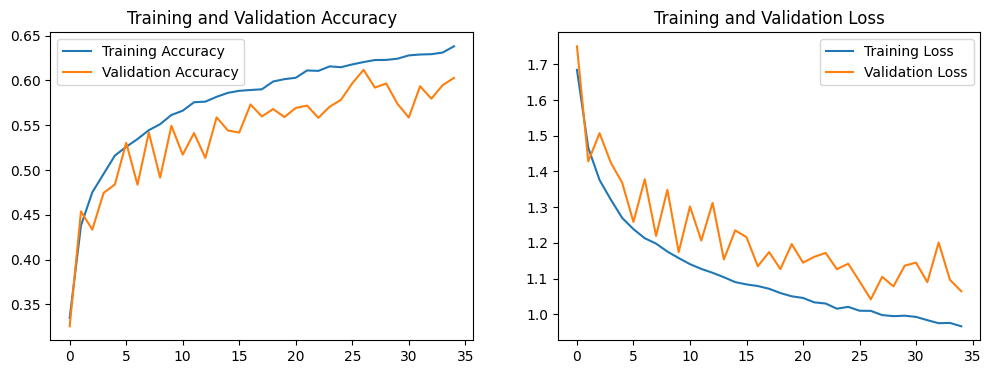

In [ ]:
# --- 1: Quick Summary ---
# Access the history dictionary
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# print(f"Final Training Accuracy: {acc[-1]*100:.2f}%")
# print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

# Verify the "Best" restored model performance
print("\n--- TRUE BEST MODEL EVALUATION ---")
test_loss, test_acc = model.evaluate(validation_generator)
print(f"True Validation Accuracy: {test_acc*100:.2f}%")

# --- 2. Visual Graphs (Accuracy & Loss) ---
import matplotlib.pyplot as plt

epochs = range(len(acc))
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Step 6: Save to Drive (Crucial)

In [ ]:
import shutil
import os
from tensorflow.keras.models import load_model

# --- STEP 1: SAVE TO DRIVE ---
# Source path (Where the checkpoint saved it in Colab)
source = 'best_fer_model.keras'

# Destination path (Your Google Drive)
# UPDATED NAME: Changed 'vgg16' to 'mini_xception' so you know what it is later
destination = '/content/drive/MyDrive/final_fer_mini_xception.keras'

# Copy the file
shutil.copy(source, destination)
print(f"✅ Model saved safely to Drive at: {destination}")

# --- STEP 2: VERIFY PERFORMANCE ---
# This confirms that the saved file actually works and gives the expected accuracy.

# 1. Load the model back from the disk
print("Loading model for verification...")
best_model = load_model('best_fer_model.keras')

# 2. Evaluate on the validation set
print("\n--- CALCULATING TRUE ACCURACY ---")
val_loss, val_accuracy = best_model.evaluate(validation_generator, verbose=1)

print(f"\nResults:")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

✅ Model saved safely to Drive at: /content/drive/MyDrive/final_fer_mini_xception.keras
Loading model for verification...

--- CALCULATING TRUE ACCURACY ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5328 - loss: 1.2256

Results:
Validation Accuracy: 61.17%
Validation Loss: 1.0415
